In [1]:
import sys
sys.path.append("..")

In [2]:
import logging

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, mean_absolute_error

from config import BATCH_SIZE, MAX_K, train_dataset_path, val_dataset_path
from src.dataset import GalacticBinariesDataset
from src.logger import setup_logging

setup_logging()

In [3]:
TRAIN_SAMPLES = 100_000
VAL_SAMPLES = 100_000
NOISE_TRAIN = True
NOISE_VAL = True
SEED_TRAIN = 42
SEED_VAL = 0

In [4]:
logger = logging.getLogger("EnergyBaseline")

In [5]:
train_dataset = GalacticBinariesDataset(
    train_dataset_path,
    max_K=MAX_K,
    max_samples=TRAIN_SAMPLES,
    noise=NOISE_TRAIN,
    deterministic=True,
    seed=SEED_TRAIN,
)
val_dataset = GalacticBinariesDataset(
    val_dataset_path,
    max_K=MAX_K,
    max_samples=VAL_SAMPLES,
    noise=NOISE_VAL,
    deterministic=True,
    seed=SEED_VAL,
)

print("Configuration")
print(f"Train dataset: {train_dataset_path}")
print(f"Val dataset:   {val_dataset_path}")
print(f"MAX_K:         {MAX_K}")
print(f"Train samples: {len(train_dataset)}")
print(f"Val samples:   {len(val_dataset)}")
print(f"Noise train:   {NOISE_TRAIN}")
print(f"Noise val:     {NOISE_VAL}")

[05/13/26 14:19:00] INFO     Loading 1048576 waveforms in memory...

[05/13/26 14:19:29] INFO     Loading parameters amp, beta, f0, fddot, fdot, iota, lam, phi0, psi in memory...

[05/13/26 14:19:31] INFO     Loading 100000 waveforms in memory...

[05/13/26 14:19:34] INFO     Loading parameters amp, beta, f0, fddot, fdot, iota, lam, phi0, psi, snr in memory...

Configuration
Train dataset: /sps/l2it/tdonze/gb-dataset-gen/data/synthetic_dataset/train_dataset_1M_diff_1.hdf5
Val dataset:   /sps/l2it/tdonze/gb-dataset-gen/data/synthetic_dataset/val_dataset_100K_diff_1.hdf5
MAX_K:         10
Train samples: 100000
Val samples:   100000
Noise train:   True
Noise val:     True


In [6]:
def collect_energy_and_labels(dataset: GalacticBinariesDataset) -> tuple[np.ndarray, np.ndarray]:
    energies = np.empty(len(dataset), dtype=np.float64)
    labels = np.empty(len(dataset), dtype=np.int64)

    for start in range(0, len(dataset), BATCH_SIZE):
        end = min(start + BATCH_SIZE, len(dataset))
        for i, dataset_idx in enumerate(range(start, end), start=start):
            waveform, target = dataset[dataset_idx]
            energies[i] = np.sum(np.asarray(waveform, dtype=np.float64) ** 2)
            labels[i] = target
    return energies, labels

In [7]:
train_energies, train_labels = collect_energy_and_labels(train_dataset)
val_energies, val_labels = collect_energy_and_labels(val_dataset)

In [8]:
def print_energy_stats(name: str, energies: np.ndarray, labels: np.ndarray) -> None:
    print(f"\n=== Energy stats: {name} ===")
    for k in range(1, MAX_K + 1):
        values = energies[labels == k]
        print(
            f"k={k:2d} | "
            f"mean={values.mean():.6g} | "
            f"std={values.std():.6g} | "
            f"p05={np.percentile(values, 5):.6g} | "
            f"p50={np.percentile(values, 50):.6g} | "
            f"p95={np.percentile(values, 95):.6g}"
        )

In [9]:
print_energy_stats("train", train_energies, train_labels)
print_energy_stats("val", val_energies, val_labels)


=== Energy stats: train ===
k= 1 | mean=4856.64 | std=634.92 | p05=3418.97 | p50=5041.27 | p95=5542.29
k= 2 | mean=9206.13 | std=978.925 | p05=7458.7 | p50=9339.36 | p95=10474
k= 3 | mean=13564.3 | std=1292.79 | p05=11312 | p50=13666.8 | p95=15409.4
k= 4 | mean=17872.8 | std=1566.71 | p05=15208.2 | p50=17934.8 | p95=20271.5
k= 5 | mean=22208 | std=1891.3 | p05=19085.4 | p50=22240.4 | p95=25148.5
k= 6 | mean=26570.4 | std=2143.71 | p05=23081.4 | p50=26585.1 | p95=30039.9
k= 7 | mean=30910 | std=2417.65 | p05=26998.4 | p50=30898.9 | p95=34917.2
k= 8 | mean=35234.6 | std=2719.58 | p05=30800.4 | p50=35191.3 | p95=39727.2
k= 9 | mean=39552 | std=3039.17 | p05=34685.4 | p50=39470.1 | p95=44566.7
k=10 | mean=43956 | std=3261.57 | p05=38690.5 | p50=43856.1 | p95=49366.6

=== Energy stats: val ===
k= 1 | mean=4850 | std=639.234 | p05=3417.17 | p50=5046 | p95=5537.1
k= 2 | mean=9200.55 | std=980.107 | p05=7425.76 | p50=9345.1 | p95=10491.8
k= 3 | mean=13533.6 | std=1292.12 | p05=11296.2 | p50=1

In [10]:
def fit_mean_energy_baseline(energies: np.ndarray, labels: np.ndarray) -> dict[int, float]:
    return {
        k: float(energies[labels == k].mean())
        for k in range(1, MAX_K + 1)
    }


def predict_from_nearest_mean(energies: np.ndarray, mean_energy_by_k: dict[int, float]) -> np.ndarray:
    classes = np.array(sorted(mean_energy_by_k), dtype=np.int64)
    means = np.array([mean_energy_by_k[k] for k in classes], dtype=np.float64)
    closest_mean_indices = np.abs(energies[:, None] - means[None, :]).argmin(axis=1)
    return classes[closest_mean_indices]

In [11]:
mean_energy_by_k = fit_mean_energy_baseline(train_energies, train_labels)
val_predictions = predict_from_nearest_mean(val_energies, mean_energy_by_k)

print("\nMean train energy by k")
for k, mean_energy in mean_energy_by_k.items():
    print(f"k={k:2d}: {mean_energy:.6g}")

accuracy = accuracy_score(val_labels, val_predictions)
f1 = f1_score(val_labels, val_predictions, average="macro", zero_division=0)
mae = mean_absolute_error(val_labels, val_predictions)

print("\n=== Baseline total energy -> k ===")
print(f"Accuracy: {accuracy:.4f}")
print(f"Macro F1: {f1:.4f}")
print(f"MAE:      {mae:.4f}")


Mean train energy by k
k= 1: 4856.64
k= 2: 9206.13
k= 3: 13564.3
k= 4: 17872.8
k= 5: 22208
k= 6: 26570.4
k= 7: 30910
k= 8: 35234.6
k= 9: 39552
k=10: 43956

=== Baseline total energy -> k ===
Accuracy: 0.7730
Macro F1: 0.7728
MAE:      0.2347


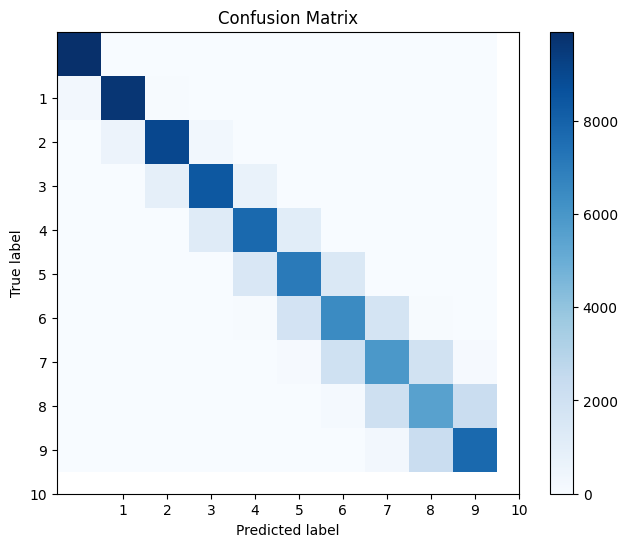

In [12]:
# plot confusion matrix
cm = confusion_matrix(val_labels, val_predictions, labels=range(1, MAX_K + 1))
plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.colorbar()
tick_marks = np.arange(1, MAX_K + 1)
plt.xticks(tick_marks, tick_marks)
plt.yticks(tick_marks, tick_marks)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.show()

In [13]:
print(confusion_matrix(val_labels, val_predictions, labels=list(range(1, MAX_K + 1))))

[[9911    0    0    0    0    0    0    0    0    0]
 [ 241 9666   57    2    0    0    0    0    0    0]
 [   0  563 9000  287    2    0    0    0    0    0]
 [   0    2  860 8363  662    5    0    0    0    0]
 [   0    0    6 1194 7709 1083    8    0    0    0]
 [   0    0    0   22 1491 7077 1425   30    1    0]
 [   0    0    0    1   44 1817 6451 1728   52    1]
 [   0    0    0    0    1  104 1998 5905 1931  104]
 [   0    0    0    0    0    2  129 2090 5499 2264]
 [   0    0    0    0    0    0    2  245 2250 7715]]
